# Fuel Market Stress and Forecasting Project

This notebook turns a generic Kaggle-style time-series walkthrough into a more original project:

- it compares **five linked energy markets** instead of studying one series in isolation
- it uses **portable file paths and helper functions** so the notebook is reusable
- it measures **volatility, drawdowns, and rolling correlation** to tell a market story
- it adds a **Jensen-Shannon divergence stress score** to detect changes in return behavior
- it finishes with a **time-based forecasting benchmark** instead of a random train/test split


## Project Questions

1. Which fuel markets were the most volatile and suffered the deepest drawdowns?
2. When did each market start behaving very differently from its historical baseline?
3. Can the recent behavior of related fuel markets help explain next-day crude oil returns?


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.spatial.distance import jensenshannon
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

plt.style.use("ggplot")
pd.options.display.float_format = "{:,.4f}".format
warnings.filterwarnings("ignore")


In [2]:
def resolve_data_path() -> Path:
    candidates = [
        Path("../Datasets") / "all_fuels_data.csv",
        Path("Datasets") / "all_fuels_data.csv",
        Path("all_fuels_data.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find all_fuels_data.csv in the project folder.")


def load_market_data(path: Path) -> pd.DataFrame:
    fuel = pd.read_csv(path, parse_dates=["date"]).sort_values(["commodity", "date"]).copy()
    fuel["daily_return"] = fuel.groupby("commodity")["close"].pct_change(fill_method=None)
    fuel["volume_change"] = fuel.groupby("commodity")["volume"].pct_change(fill_method=None)
    fuel["rolling_vol_21"] = (
        fuel.groupby("commodity")["daily_return"]
        .transform(lambda s: s.rolling(21).std() * np.sqrt(252))
    )
    fuel["drawdown"] = fuel.groupby("commodity")["close"].transform(
        lambda s: s / s.cummax() - 1
    )
    return fuel


def build_normalized_index(fuel: pd.DataFrame) -> pd.DataFrame:
    wide_close = fuel.pivot(index="date", columns="commodity", values="close").sort_index()
    return wide_close.apply(
        lambda s: (s / s.dropna().iloc[0]) * 100 if s.notna().any() else s
    )


def rolling_js_divergence(
    fuel: pd.DataFrame,
    window: int = 126,
    baseline_window: int = 756,
    bins: np.ndarray | None = None,
) -> pd.DataFrame:
    if bins is None:
        bins = np.linspace(-0.30, 0.30, 61)

    records = []
    lower = bins[0] + 1e-9
    upper = bins[-1] - 1e-9

    for commodity, group in fuel.groupby("commodity"):
        data = group.dropna(subset=["daily_return"]).copy()
        values = data["daily_return"].clip(lower, upper).to_numpy()

        if len(values) < baseline_window + window:
            continue

        baseline = values[:baseline_window]
        baseline_hist, _ = np.histogram(baseline, bins=bins, density=True)
        baseline_hist = np.where(baseline_hist <= 0, 1e-12, baseline_hist)
        baseline_hist = baseline_hist / baseline_hist.sum()

        for end in range(window, len(values) + 1):
            current = values[end - window:end]
            current_hist, _ = np.histogram(current, bins=bins, density=True)
            current_hist = np.where(current_hist <= 0, 1e-12, current_hist)
            current_hist = current_hist / current_hist.sum()

            records.append(
                {
                    "commodity": commodity,
                    "date": data.iloc[end - 1]["date"],
                    "js_divergence": float(
                        jensenshannon(current_hist, baseline_hist, base=2.0) ** 2
                    ),
                }
            )

    return pd.DataFrame(records)


def build_forecast_frame(
    fuel: pd.DataFrame,
    target_commodity: str = "Crude Oil",
) -> pd.DataFrame:
    close_wide = fuel.pivot(index="date", columns="commodity", values="close").sort_index()
    volume_wide = fuel.pivot(index="date", columns="commodity", values="volume").sort_index()

    returns = (
        close_wide.pct_change(fill_method=None)
        .replace([np.inf, -np.inf], np.nan)
        .clip(-0.25, 0.25)
    )
    volume_change = (
        volume_wide.pct_change(fill_method=None)
        .replace([np.inf, -np.inf], np.nan)
        .clip(-1.0, 1.0)
    )

    frame = pd.DataFrame(index=close_wide.index)

    for commodity in close_wide.columns:
        safe_name = commodity.lower().replace(" ", "_")
        frame[f"{safe_name}_ret_lag_1"] = returns[commodity].shift(1)
        frame[f"{safe_name}_ret_lag_2"] = returns[commodity].shift(2)
        frame[f"{safe_name}_ret_lag_5"] = returns[commodity].rolling(5).mean().shift(1)
        frame[f"{safe_name}_vol_21"] = returns[commodity].rolling(21).std().shift(1)
        frame[f"{safe_name}_volchg_1"] = volume_change[commodity].shift(1)

    frame["target_return"] = returns[target_commodity].shift(-1)
    return frame.dropna()


In [3]:
data_path = resolve_data_path()
fuel = load_market_data(data_path)

project_summary = (
    fuel.groupby("commodity")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "size"),
        avg_close=("close", "mean"),
        avg_volume=("volume", "mean"),
    )
    .sort_values("start_date")
)

print(f"Loaded data from: {data_path}")
display(project_summary)
fuel.head()


Loaded data from: all_fuels_data.csv


,start_date,end_date,observations,avg_close,avg_volume
commodity,,,,,
Crude Oil,2000-08-23,2024-06-24,5984,64.4775,"303,768.3399"
Natural Gas,2000-08-30,2024-06-24,5980,4.4683,"102,846.4816"
Heating Oil,2000-09-01,2024-06-24,5977,1.9877,"38,459.3005"
RBOB Gasoline,2000-11-01,2024-06-24,5938,1.9117,"40,308.6940"
Brent Crude Oil,2007-07-30,2024-06-24,4196,78.7185,"17,575.0801"


,ticker,commodity,date,open,high,low,close,volume,daily_return,volume_change,rolling_vol_21,drawdown
23879,BZ=F,Brent Crude Oil,2007-07-30,75.8500,76.5300,75.4400,75.7400,2575,NaN,NaN,NaN,0.0000
23880,BZ=F,Brent Crude Oil,2007-07-31,75.7000,77.1700,75.6700,77.0500,3513,0.0173,0.3643,NaN,0.0000
23881,BZ=F,Brent Crude Oil,2007-08-01,77.0000,77.0600,74.8600,75.3500,3930,-0.0221,0.1187,NaN,-0.0221
23882,BZ=F,Brent Crude Oil,2007-08-02,75.2200,76.2100,74.2700,75.7600,6180,0.0054,0.5725,NaN,-0.0167
23883,BZ=F,Brent Crude Oil,2007-08-03,75.3900,76.0000,74.5300,74.7500,4387,-0.0133,-0.2901,NaN,-0.0299


## 1. Data Audit

Before modeling or plotting, we should check whether the market history contains unusual values.
This matters here because crude oil briefly traded at a **negative closing price on April 20, 2020**,
which is real but can distort naive transformations such as log returns.


In [4]:
quality_check = (
    fuel.groupby("commodity")
    .agg(
        missing_close=("close", lambda s: int(s.isna().sum())),
        min_close=("close", "min"),
        max_close=("close", "max"),
        min_return=("daily_return", "min"),
        max_return=("daily_return", "max"),
    )
    .sort_index()
)

negative_close_rows = fuel.loc[fuel["close"] <= 0, ["commodity", "date", "close", "volume"]]
deepest_drawdowns = (
    fuel.groupby("commodity")["drawdown"]
    .min()
    .sort_values()
    .rename("deepest_drawdown")
    .to_frame()
)

display(quality_check)
display(negative_close_rows)
display(deepest_drawdowns)


,missing_close,min_close,max_close,min_return,max_return
commodity,,,,,
Brent Crude Oil,0,19.3300,146.0800,-0.2440,0.3155
Crude Oil,0,-37.6300,145.2900,-3.0597,0.3766
Heating Oil,0,0.4999,5.1354,-0.2193,0.1315
Natural Gas,0,1.4820,15.3780,-0.2595,0.4648
RBOB Gasoline,0,0.4118,4.2762,-0.3198,0.2510


,commodity,date,close,volume
4931,Crude Oil,2020-04-20,-37.6300,247947


,deepest_drawdown
commodity,
Crude Oil,-1.2590
Natural Gas,-0.9036
RBOB Gasoline,-0.8847
Brent Crude Oil,-0.8677
Heating Oil,-0.8513


## 2. Long-Run Price Paths

Normalizing each series to 100 at its own start date makes it easier to compare how the markets evolved
even though they have different price scales and different listing dates.


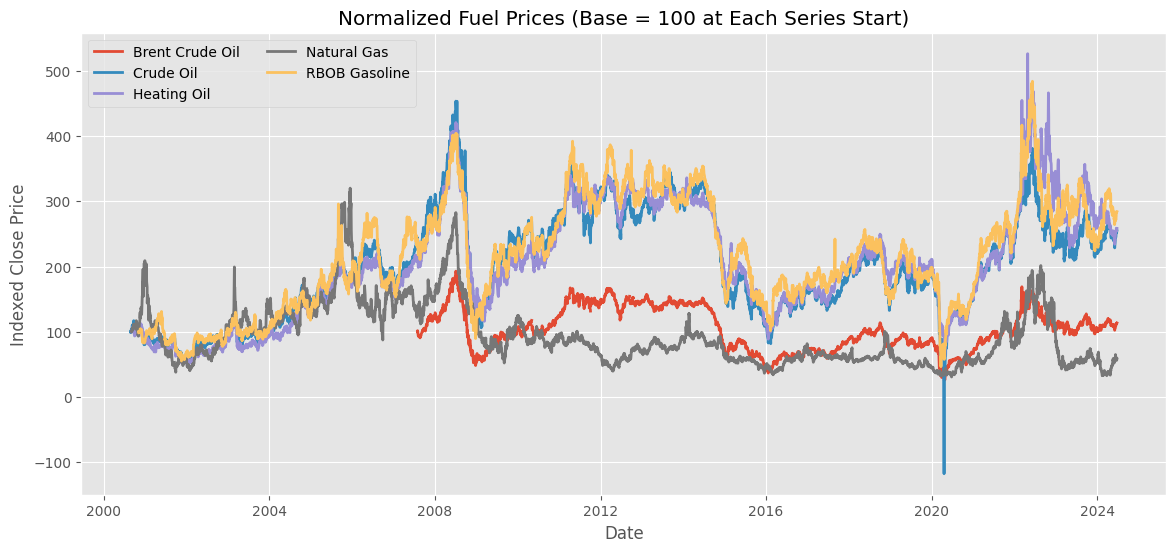

In [5]:
normalized_index = build_normalized_index(fuel)

fig, ax = plt.subplots(figsize=(14, 6))
for column in normalized_index.columns:
    ax.plot(normalized_index.index, normalized_index[column], linewidth=2, label=column)

ax.set_title("Normalized Fuel Prices (Base = 100 at Each Series Start)")
ax.set_ylabel("Indexed Close Price")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=2)
plt.show()


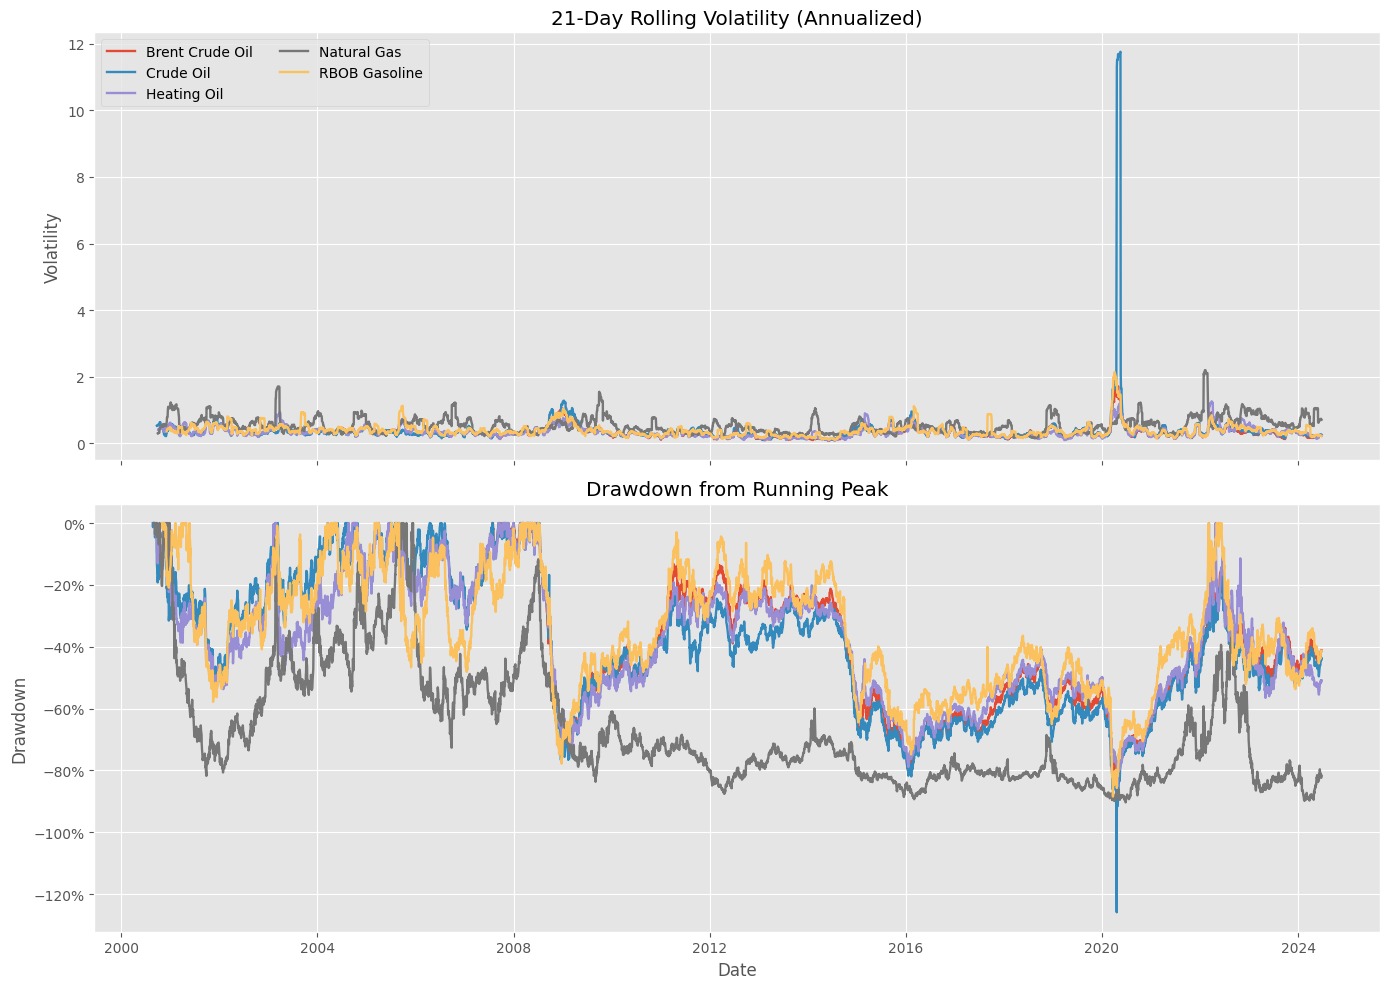

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for commodity, group in fuel.groupby("commodity"):
    axes[0].plot(group["date"], group["rolling_vol_21"], linewidth=1.7, label=commodity)
    axes[1].plot(group["date"], group["drawdown"], linewidth=1.7, label=commodity)

axes[0].set_title("21-Day Rolling Volatility (Annualized)")
axes[0].set_ylabel("Volatility")
axes[0].legend(loc="upper left", ncol=2)

axes[1].set_title("Drawdown from Running Peak")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


## 3. Cross-Market Dependence

A Kaggle notebook often stops at univariate charts. A stronger project asks how these markets move together.
The next two views show both the long-run correlation structure and the shorter rolling link with crude oil.


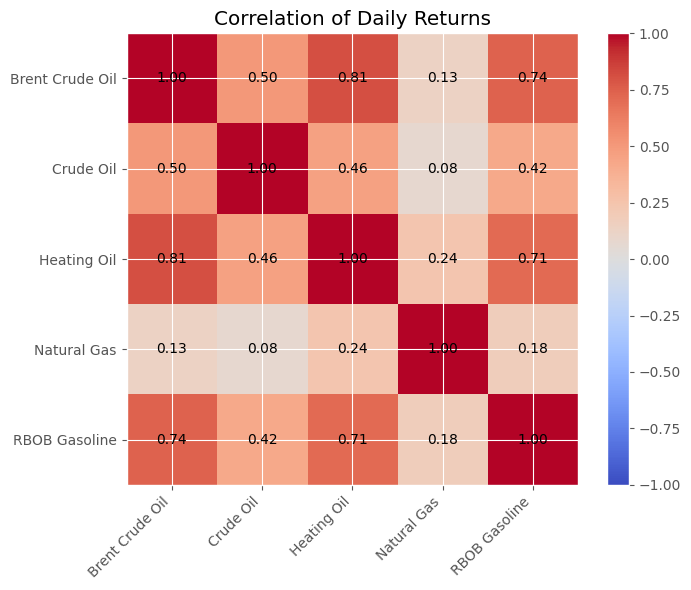

commodity,Brent Crude Oil,Crude Oil,Heating Oil,Natural Gas,RBOB Gasoline
commodity,,,,,
Brent Crude Oil,1.0000,0.5019,0.8082,0.1272,0.7418
Crude Oil,0.5019,1.0000,0.4553,0.0779,0.4194
Heating Oil,0.8082,0.4553,1.0000,0.2379,0.7055
Natural Gas,0.1272,0.0779,0.2379,1.0000,0.1752
RBOB Gasoline,0.7418,0.4194,0.7055,0.1752,1.0000


In [7]:
return_wide = fuel.pivot(index="date", columns="commodity", values="daily_return").sort_index()
corr = return_wide.corr()

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation of Daily Returns")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr


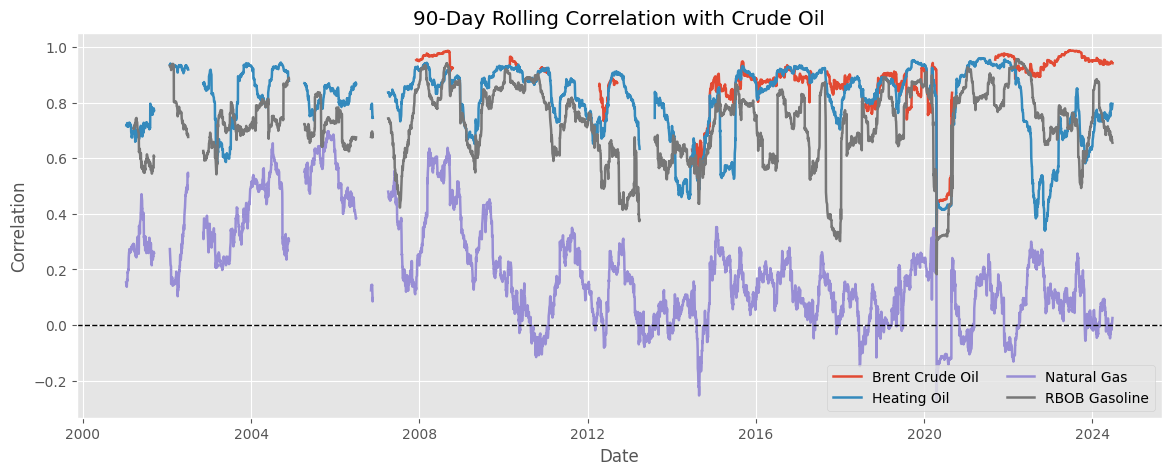

In [8]:
rolling_corr = pd.DataFrame(
    {
        commodity: return_wide["Crude Oil"].rolling(90).corr(return_wide[commodity])
        for commodity in return_wide.columns
        if commodity != "Crude Oil"
    }
)

fig, ax = plt.subplots(figsize=(14, 5))
for column in rolling_corr.columns:
    ax.plot(rolling_corr.index, rolling_corr[column], linewidth=1.8, label=column)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("90-Day Rolling Correlation with Crude Oil")
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.legend(loc="lower right", ncol=2)
plt.show()


## 4. Regime Change Detection with Jensen-Shannon Divergence

This is the main project upgrade. Instead of only plotting prices, we compare each market's recent return
distribution with its own historical baseline. Higher divergence means the market has shifted into a very
different behavioral regime.


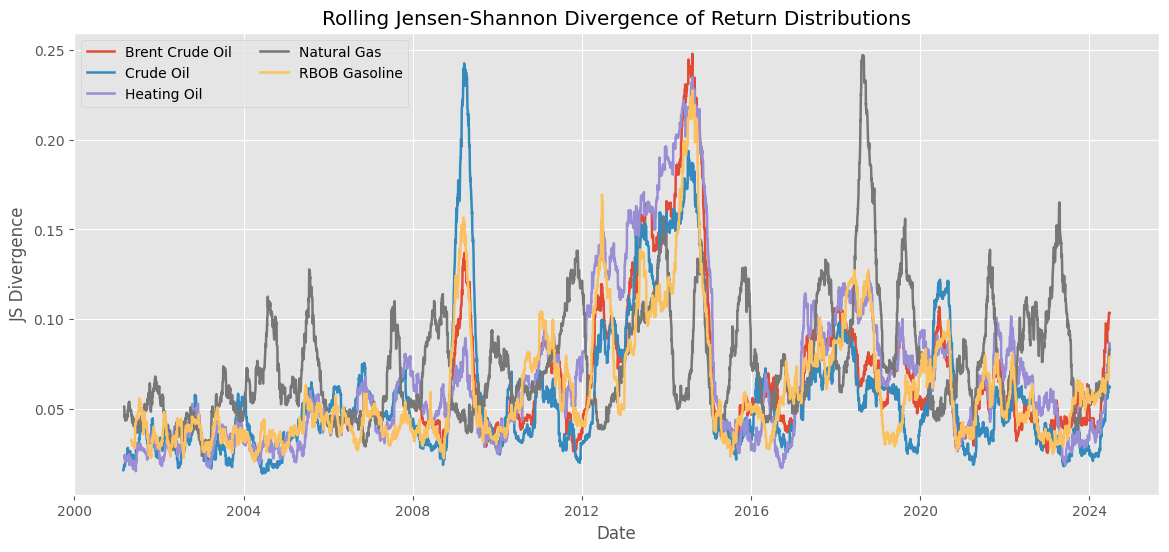

,commodity,date,js_divergence
0,Brent Crude Oil,2014-08-11,0.2479
1,Brent Crude Oil,2014-08-12,0.2447
2,Brent Crude Oil,2014-07-09,0.2446
3,Crude Oil,2009-03-20,0.2425
4,Crude Oil,2009-03-23,0.2399
5,Crude Oil,2009-03-16,0.2399
6,Heating Oil,2014-08-12,0.2348
7,Heating Oil,2014-08-11,0.2339
8,Heating Oil,2014-08-05,0.2317
9,Natural Gas,2018-08-23,0.2471


In [9]:
stress = rolling_js_divergence(fuel, window=126, baseline_window=756)

fig, ax = plt.subplots(figsize=(14, 6))
for commodity, group in stress.groupby("commodity"):
    ax.plot(group["date"], group["js_divergence"], linewidth=1.8, label=commodity)

ax.set_title("Rolling Jensen-Shannon Divergence of Return Distributions")
ax.set_ylabel("JS Divergence")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=2)
plt.show()

top_stress_dates = (
    stress.sort_values("js_divergence", ascending=False)
    .groupby("commodity")
    .head(3)
    .sort_values(["commodity", "js_divergence"], ascending=[True, False])
    .reset_index(drop=True)
)

display(top_stress_dates)


## 5. Forecasting Benchmark

To keep the notebook realistic, we use a strict **time-based split** and predict the next-day crude oil
return from lagged returns, rolling volatility, and volume changes across all markets. This is still a simple
benchmark, but it is much closer to a project workflow than a one-shot Kaggle chart notebook.


In [10]:
forecast_frame = build_forecast_frame(fuel, target_commodity="Crude Oil")

split_idx = int(len(forecast_frame) * 0.8)
train = forecast_frame.iloc[:split_idx]
test = forecast_frame.iloc[split_idx:]

X_train = train.drop(columns="target_return")
y_train = train["target_return"]
X_test = test.drop(columns="target_return")
y_test = test["target_return"]

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = pd.Series(ridge.predict(X_test), index=X_test.index, name="ridge_prediction")
naive_pred = X_test["crude_oil_ret_lag_1"].rename("naive_prediction")

metrics = pd.DataFrame(
    [
        {
            "model": "Ridge",
            "MAE": mean_absolute_error(y_test, ridge_pred),
            "RMSE": mean_squared_error(y_test, ridge_pred) ** 0.5,
            "R2": r2_score(y_test, ridge_pred),
            "direction_accuracy": (np.sign(ridge_pred) == np.sign(y_test)).mean(),
        },
        {
            "model": "Naive last return",
            "MAE": mean_absolute_error(y_test, naive_pred),
            "RMSE": mean_squared_error(y_test, naive_pred) ** 0.5,
            "R2": r2_score(y_test, naive_pred),
            "direction_accuracy": (np.sign(naive_pred) == np.sign(y_test)).mean(),
        },
    ]
).set_index("model")

top_coefficients = (
    pd.Series(ridge.coef_, index=X_train.columns)
    .sort_values(key=np.abs, ascending=False)
    .head(12)
    .rename("coefficient")
    .to_frame()
)

display(metrics.round(4))
display(top_coefficients.round(4))


,MAE,RMSE,R2,direction_accuracy
model,,,,
Ridge,0.0189,0.0249,-0.0142,0.4911
Naive last return,0.0274,0.0359,-1.1208,0.4527


,coefficient
crude_oil_ret_lag_2,-0.0655
crude_oil_ret_lag_1,-0.0513
rbob_gasoline_ret_lag_5,0.0485
rbob_gasoline_ret_lag_2,-0.0427
crude_oil_vol_21,0.0415
rbob_gasoline_ret_lag_1,0.0331
crude_oil_ret_lag_5,0.0278
brent_crude_oil_ret_lag_2,0.0263
natural_gas_ret_lag_2,0.0211
heating_oil_vol_21,0.0171


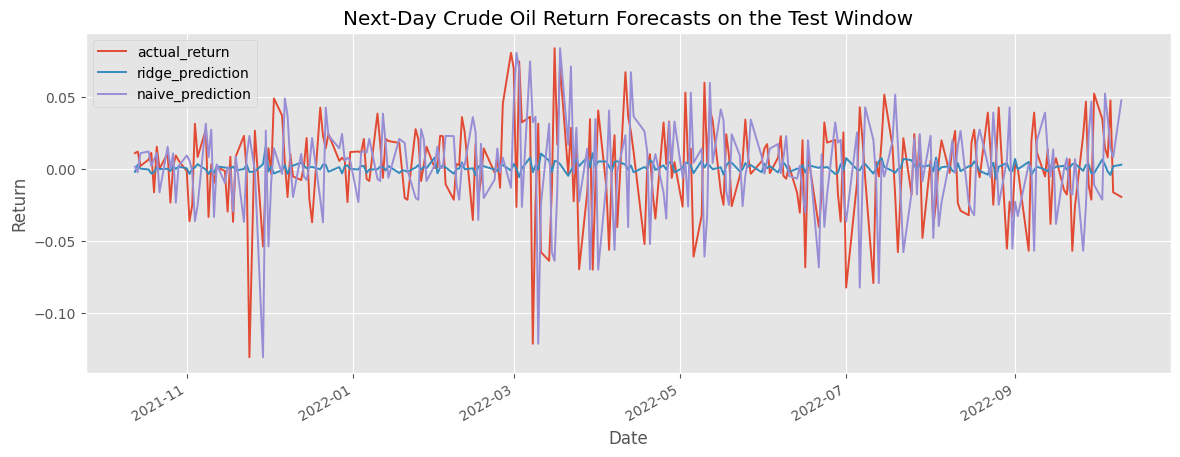

,actual_return,ridge_prediction,naive_prediction
date,,,
2021-10-13,0.0108,-0.0021,0.0015
2021-10-14,0.0119,0.0028,-0.0025
2021-10-15,0.0019,0.0001,0.0108
2021-10-18,0.0063,-0.0005,0.0119
2021-10-19,0.0110,-0.0033,0.0019


In [11]:
forecast_results = pd.concat(
    [
        y_test.rename("actual_return"),
        ridge_pred,
        naive_pred,
    ],
    axis=1,
)

fig, ax = plt.subplots(figsize=(14, 5))
forecast_results.iloc[:250].plot(ax=ax, linewidth=1.4)
ax.set_title("Next-Day Crude Oil Return Forecasts on the Test Window")
ax.set_ylabel("Return")
ax.set_xlabel("Date")
plt.show()

forecast_results.head()


## What Makes This Notebook Yours

If you want to keep developing this into a portfolio project, the next strong extensions would be:

- turn the stress score into an **alerting dashboard**
- add **event annotations** for crises such as 2008, April 2020, and 2022 energy shocks
- test **weekly and monthly forecast horizons**
- add **feature importance tracking over time**
- package the helper functions into a small Python module and build a Streamlit or Flask frontend
